# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

  


Dataset yang digunakan diambil dari :  https://www.kaggle.com/datasets/sananmuzaffarov/epl-202526-player-stats-gw131

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [9]:
df = pd.read_csv('premier_league_complete_stats_until31thGameDayOnSeason2025-26_raw.csv', encoding='latin-1')
print(f"Dataset dimuat dengan {df.shape[0]} baris dan {df.shape[1]} kolom.")
df.head()

Dataset dimuat dengan 517 baris dan 99 kolom.


,player_name,team_name,position,accurateCrosses,accurateCrossesPercentage,accurateFinalThirdPasses,accurateLongBalls,accurateLongBallsPercentage,accurateOppositionHalfPasses,accurateOwnHalfPasses,...,totalDuelsWonPercentage,totalLongBalls,totalOppositionHalfPasses,totalOwnHalfPasses,totalPasses,totalShots,totwAppearances,touches,wasFouled,yellowCards
0,Declan Rice,Arsenal,M,41,28.082192,459,72,48.648649,891,687,...,61.111111,148,1054,743,1797,36,3,2327,8,2
1,Gabriel Magalhães,Arsenal,D,1,20.000000,180,63,46.323529,512,747,...,70.334928,136,622,797,1419,18,5,1747,27,3
2,Bukayo Saka,Arsenal,F,36,32.432432,300,14,36.842105,419,105,...,53.020134,38,557,126,683,63,4,1236,51,1
3,Martín Zubimendi,Arsenal,M,2,18.181818,369,48,49.484536,833,661,...,60.189573,97,985,709,1694,26,2,2026,10,4
4,Max Dowman,Arsenal,M,0,0.000000,9,0,0.000000,13,3,...,42.857143,0,14,3,17,5,0,51,4,0


In [10]:
print("Informasi Dataset:")
df.info()

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 99 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   player_name                   517 non-null    object 
 1   team_name                     517 non-null    object 
 2   position                      517 non-null    object 
 3   accurateCrosses               517 non-null    int64  
 4   accurateCrossesPercentage     517 non-null    float64
 5   accurateFinalThirdPasses      517 non-null    int64  
 6   accurateLongBalls             517 non-null    int64  
 7   accurateLongBallsPercentage   517 non-null    float64
 8   accurateOppositionHalfPasses  517 non-null    int64  
 9   accurateOwnHalfPasses         517 non-null    int64  
 10  accuratePasses                517 non-null    int64  
 11  accuratePassesPercentage      517 non-null    float64
 12  aerialDuelsWon                517 non-null   

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [11]:
# Cek Missing Value
missing_values = df.isnull().sum()
print("Kolom dengan data kosong:")
print(missing_values[missing_values > 0])

# Menghitung total baris yang duplikat
total_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat: {total_duplikat}")


Kolom dengan data kosong:
expectedAssists      4
expectedGoals       86
goalsPrevented     483
dtype: int64
Jumlah baris duplikat: 0


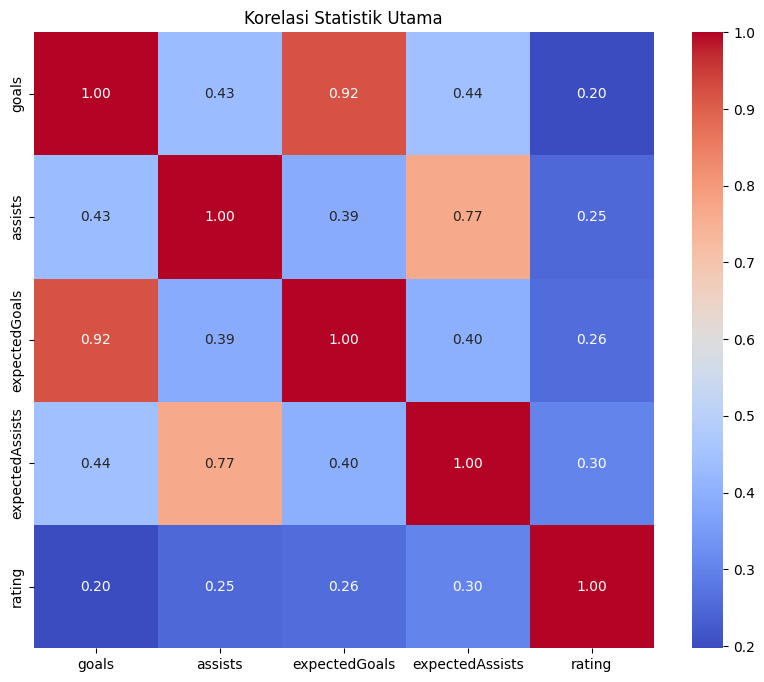

In [12]:
# Korelasi antar statistik utama (Goals, Assists, xG, xA, rating)
main_stats = ['goals', 'assists', 'expectedGoals', 'expectedAssists', 'rating']
plt.figure(figsize=(10, 8))
sns.heatmap(df[main_stats].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Statistik Utama')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [13]:
def handle_outliers(df, columns):
    df_outlier = df.copy()
    for col in columns:
        Q1 = df_outlier[col].quantile(0.25)
        Q3 = df_outlier[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_outlier[col] = df_outlier[col].clip(lower=lower_bound, upper=upper_bound)
    return df_outlier

def preprocess_data(data):
    df_clean = data.copy()

    # 1. Menangani Missing Values
    df_clean['goalsPrevented'] = df_clean['goalsPrevented'].fillna(0)
    df_clean['expectedGoals'] = df_clean['expectedGoals'].fillna(0)
    df_clean['expectedAssists'] = df_clean['expectedAssists'].fillna(0)

   # 2. Penanganan Outlier dengan Capping (IQR)
    numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
    if 'rating' in numeric_cols: numeric_cols.remove('rating')
    df_clean = handle_outliers(df_clean, numeric_cols)

    # 3. Drop kolom identitas
    df_clean = df_clean.drop(columns=['player_name'], errors='ignore')

    # 4. Feature Selection & Transformer Definition
    categorical_features = ['position', 'team_name']

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ])

    # Pisahkan Fitur dan Target
    X = df_clean.drop(columns=['rating'])
    y = df_clean['rating']

    return X, y, preprocessor

# Eksekusi fungsi eksperimen
X, y, transformer = preprocess_data(df)
print("Preprocessing selesai")

X_transformed = transformer.fit_transform(X)
print(f"Ukuran data setelah transformasi: {X_transformed.shape}")
print("Contoh data hasil standarisasi (baris 1):")
print(X_transformed[0])

Preprocessing selesai
Ukuran data setelah transformasi: (517, 119)
Contoh data hasil standarisasi (baris 1):
[ 2.34359882  0.75477565  2.50494003  2.21811643  0.36275196  2.63574255
  2.23042359  2.68347744  0.79102131  1.47655159  1.18227212 -0.08784757
  1.25857823  2.9098893   2.15189137  2.60344768  0.98954434  1.34994532
  2.79352568  1.24727709  0.47308002  0.53731623  0.34933768  0.
 -0.79271676  2.53933316  0.98635374  0.64848371  0.          0.54538707
  1.63078617  2.24110597  0.24014019 -0.04209951  1.67494099  1.19364151
  0.          0.          1.04419634  0.43824898  0.          0.
 -0.58315976  1.70657791  1.95949806  2.76569979  0.          1.61228701
  1.65476948 -0.2068756   0.          0.          0.          0.
  0.          0.          0.          0.          0.          2.06497876
  1.42153635  0.          0.          2.13114885  0.          0.
  0.          0.          0.          0.6335975   0.          0.
  0.3833499   2.46479727  1.65289625  1.43865287  0.571

In [15]:
# ! python automate_Wahyudi-Putra.py

Preprocessing completed. Dataset berhasil disimpan di: processed_data.csv
